# 训练数据验证

验证 Phase A（Bottleneck SFT）和 Phase B（Self-distillation）所用数据是否与论文 arXiv:2604.22709 描述一致。

**数据来源：** `allenai/Dolci-Think-SFT-7B`（HF 流式，无需全量下载）  
**代码来源：** `src/data_utils.py`（原样 import，不重写逻辑）

In [1]:
import sys, json, re, random
sys.path.insert(0, "../src")

import datasets
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter
from IPython.display import display
import pandas as pd

TH = re.compile(r"<think>(.*?)</think>", re.S)

## 1. 原始数据集结构
先看 HF 上 `allenai/Dolci-Think-SFT-7B` 的原始行长什么样。

In [ ]:
# 流式读取，只取前 5 条，不用下载完整数据集
raw_ds = datasets.load_dataset("allenai/Dolci-Think-SFT-7B", split="train", streaming=True)
raw_samples = list(raw_ds.take(5))

print(f"字段名: {list(raw_samples[0].keys())}\n")
r = raw_samples[0]
print(f"id            : {r.get('id')}")
print(f"dataset_source: {r.get('dataset_source')}")
print(f"messages 数量 : {len(r.get('messages', []))}")
for i, m in enumerate(r.get("messages", [])):
    role = m.get("role")
    content_preview = str(m.get("content", ""))[:200].replace("\n", " ")
    print(f"  messages[{i}] role={role}: {content_preview}...")

Resolving data files:   0%|          | 0/156 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/156 [00:00<?, ?it/s]

字段名: ['messages', 'dataset_source', 'id']

id            : tulu_v3.9_wildchat_100k_english-r1-final-content-filtered_0
dataset_source: allenai/tulu_v3.9_wildchat_100k_english-r1-final-content-filtered
messages 数量 : 2
  messages[0] role=user: Please translate the following paragraph into Chinese:"In light of high risks of China’s economic outlook, rising geopolitical tensions could disrupt economic activity and dampen business and consumer...
  messages[1] role=assistant: <think>  </think>  鉴于中国经济前景面临的高风险，地缘政治紧张局势的加剧可能扰乱经济活动，抑制企业和消费者信心。从外部环境来看，全球衰退程度加深且持续时间延长，以及中国与其主要贸易伙伴之间的双边紧张关系升级，也可能阻碍经济复苏进程。...


## 2. download_data.py 的过滤逻辑

脚本从 `messages[-1]`（assistant 回复）里提取 `<think>...</think>` 作为 CoT，剩余文本作为 answer。

In [3]:
def parse_row(ex):
    """复现 download_data.py 的提取逻辑。"""
    msgs = ex.get("messages") or []
    if len(msgs) < 2 or msgs[-1].get("role") != "assistant":
        return None
    user = next((m["content"] for m in msgs if m.get("role") == "user"), None)
    assistant = msgs[-1]["content"]
    if not user or not assistant:
        return None
    m = TH.search(assistant)
    if not m:
        return None
    cot = m.group(1).strip()
    answer = TH.sub("", assistant).strip()
    if len(cot) < 200 or len(answer) < 5:
        return None
    return {
        "id": ex.get("id"),
        "source": ex.get("dataset_source", "?"),
        "prompt": user,
        "cot": cot,
        "answer": answer,
    }

# 从前 50 条原始数据中提取
raw_50 = list(raw_ds.take(50))
parsed = [r for raw in raw_50 if (r := parse_row(raw)) is not None]

print(f"原始 50 条 → 过滤后 {len(parsed)} 条")
print(f"\n--- 第一条解析结果 ---")
p = parsed[0]
print(f"source : {p['source']}")
print(f"prompt : {p['prompt'][:300]}...")
print(f"\ncot    ({len(p['cot'])} chars): {p['cot'][:400]}...")
print(f"\nanswer ({len(p['answer'])} chars): {p['answer'][:300]}")

原始 50 条 → 过滤后 44 条

--- 第一条解析结果 ---
source : allenai/tulu_v3.9_wildchat_100k_english-r1-final-content-filtered
prompt : Hello there!...

cot    (561 chars): Okay, the user greeted me with "Hello there!" I need to respond in a friendly and welcoming manner. Let me start by acknowledging their greeting. Maybe say something like, "Hello! How can I assist you today?" That's standard but polite. I should keep it open-ended to encourage them to ask for help. Also, since I'm DeepSeek-R1, I should mention that I'm here to help. Maybe add a smiley emoji to kee...

answer (129 chars): Hello! 👋 How can I assist you today? Whether you have questions, need help with a task, or just want to chat, I'm here to help! 😊


## 3. 批量采样 + 统计

流式取 500 条（shuffle buffer=2000）来看 source 分布和 CoT 长度分布。

In [4]:
raw_shuffled = datasets.load_dataset(
    "allenai/Dolci-Think-SFT-7B", split="train", streaming=True
).shuffle(seed=42, buffer_size=2000)

sample500 = []
for raw in raw_shuffled:
    r = parse_row(raw)
    if r:
        sample500.append(r)
    if len(sample500) >= 500:
        break

print(f"采集到 {len(sample500)} 条")

Resolving data files:   0%|          | 0/156 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/156 [00:00<?, ?it/s]

采集到 500 条


,source,count
0,saumyamalik/OpenThoughts3-full-filtered-math-d...,500


/tmp/ipykernel_8145/200926397.py:25: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/200926397.py:25: UserWarning: Glyph 31526 (\N{CJK UNIFIED IDEOGRAPH-7B26}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/200926397.py:25: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/200926397.py:25: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/200926397.py:25: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/200926397.py:25: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/200926397.py:25: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missi

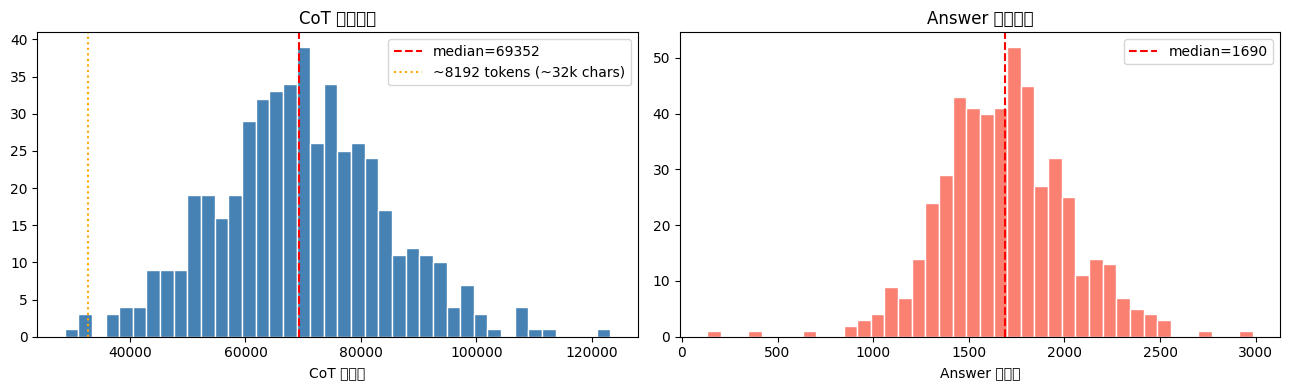


CoT 长度: min=28683, median=69352, max=123177
Answer 长度: min=132, median=1690, max=2984


In [5]:
# source 分布
src_counts = Counter(r["source"] for r in sample500)
df_src = pd.DataFrame(src_counts.most_common(15), columns=["source", "count"])
display(df_src)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# CoT 长度分布
cot_lens = [len(r["cot"]) for r in sample500]
axes[0].hist(cot_lens, bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(np.median(cot_lens), color="red", linestyle="--", label=f"median={int(np.median(cot_lens))}")
axes[0].axvline(8192*4, color="orange", linestyle=":", label="~8192 tokens (~32k chars)")
axes[0].set_xlabel("CoT 字符数")
axes[0].set_title("CoT 长度分布")
axes[0].legend()

# answer 长度分布
ans_lens = [len(r["answer"]) for r in sample500]
axes[1].hist(ans_lens, bins=40, color="salmon", edgecolor="white")
axes[1].axvline(np.median(ans_lens), color="red", linestyle="--", label=f"median={int(np.median(ans_lens))}")
axes[1].set_xlabel("Answer 字符数")
axes[1].set_title("Answer 长度分布")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"\nCoT 长度: min={min(cot_lens)}, median={int(np.median(cot_lens))}, max={max(cot_lens)}")
print(f"Answer 长度: min={min(ans_lens)}, median={int(np.median(ans_lens))}, max={max(ans_lens)}")

## 4. Phase A — Bottleneck 样本构造

论文 §3.2：训练序列为 `[X; C; Z̃; Y]`，attention mask 禁止 Y 看到 C。  
直接用 `src/data_utils.py` 的 `build_bottleneck_example()`，不重写逻辑。

In [6]:
# 加载 tokenizer（用已下载的 final/ 模型）
from transformers import AutoTokenizer
from abstract import BEGIN_ABS, END_ABS, abstract_token_strings, all_new_tokens
from data_utils import (
    build_bottleneck_example,
    build_distill_example,
    random_abstract_trace,
)

MODEL_PATH = "../runs_hf/final"
tok = AutoTokenizer.from_pretrained(MODEL_PATH)

# 取 abstract token ids
abs_strs = abstract_token_strings(64)
abs_ids = [tok.convert_tokens_to_ids(t) for t in abs_strs]
begin_id = tok.convert_tokens_to_ids(BEGIN_ABS)
end_id   = tok.convert_tokens_to_ids(END_ABS)

print(f"BEGIN_ABS id : {begin_id}  ({BEGIN_ABS})")
print(f"END_ABS id   : {end_id}  ({END_ABS})")
print(f"V_abs size   : {len(abs_ids)}  (ids {abs_ids[0]}..{abs_ids[-1]})")

BEGIN_ABS id : 151669  (<beginabstract>)
END_ABS id   : 151670  (<endabstract>)
V_abs size   : 64  (ids 151671..151734)


In [7]:
# 用 sample500[0] 构造一个 Phase A bottleneck example
row = sample500[0]
trace = random_abstract_trace(64, abs_ids, m_min=16, m_max=64)  # round 1: random trace

ex = build_bottleneck_example(
    tok, row["prompt"], row["cot"], row["answer"],
    abs_trace_ids=trace,
    begin_id=begin_id, end_id=end_id,
    max_len=8192,
)

if ex is None:
    print("example was None (too long even after truncation — try next row)")
else:
    lenX, lenC, lenZ, lenY = ex["lens"]
    total = lenX + lenC + lenZ + lenY
    print(f"序列总长度: {total} tokens")
    print(f"  X (prompt prefix) : {lenX} tokens")
    print(f"  C (verbal CoT)    : {lenC} tokens  ← Round 1 时最可能被截断")
    print(f"  Z̃ (abstract trace): {lenZ} tokens  (含 begin/end delimiters)")
    print(f"  Y (answer)        : {lenY} tokens")
    
    # 验证 labels 只在 Z̃ ∪ Y 上有值
    labels = ex["labels"]
    loss_positions = [i for i, l in enumerate(labels) if l != -100]
    z_start = lenX + lenC
    print(f"\nloss 计算位置: {loss_positions[0]}..{loss_positions[-1]}")
    print(f"Z̃ 开始位置  : {z_start}")
    print(f"✓ loss 只在 Z̃∪Y 上" if loss_positions[0] == z_start else "✗ 位置不对")

序列总长度: 8192 tokens
  X (prompt prefix) : 206 tokens
  C (verbal CoT)    : 7506 tokens  ← Round 1 时最可能被截断
  Z̃ (abstract trace): 33 tokens  (含 begin/end delimiters)
  Y (answer)        : 447 tokens

loss 计算位置: 7712..8191
Z̃ 开始位置  : 7712
✓ loss 只在 Z̃∪Y 上


/tmp/ipykernel_8145/758992068.py:35: UserWarning: Glyph 34987 (\N{CJK UNIFIED IDEOGRAPH-88AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/758992068.py:35: UserWarning: Glyph 30475 (\N{CJK UNIFIED IDEOGRAPH-770B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/758992068.py:35: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/758992068.py:35: UserWarning: Glyph 21457 (\N{CJK UNIFIED IDEOGRAPH-53D1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/758992068.py:35: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/758992068.py:35: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/758992068.py:35: UserWarning: Glyph 34013 (\N{CJK UNIFIED IDEOGRAPH-84DD}) missi

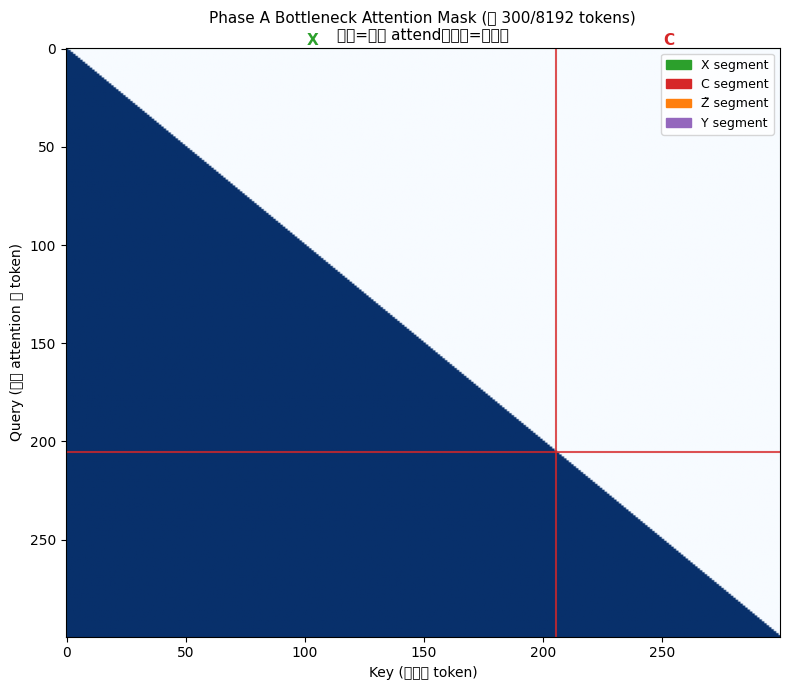


验证 Y→C 屏蔽: mask[Y_rows, C_cols] 中 True 的比例 = 0.0000
✓ Y 完全看不到 C（全为 False）


In [8]:
# 可视化 attention mask（截取前 300 个 token 看清结构）
if ex is not None:
    lenX, lenC, lenZ, lenY = ex["lens"]
    mask = ex["attn_mask_2d"].float().numpy()  # (T, T), True=attend
    VIS = min(300, mask.shape[0])
    
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(mask[:VIS, :VIS], cmap="Blues", aspect="auto", vmin=0, vmax=1)
    
    # 标注分段边界
    boundaries = [
        (0,    lenX,         "X",  "#2ca02c"),
        (lenX, lenX+lenC,    "C",  "#d62728"),
        (lenX+lenC, lenX+lenC+lenZ, "Z̃", "#ff7f0e"),
        (lenX+lenC+lenZ, lenX+lenC+lenZ+lenY, "Y", "#9467bd"),
    ]
    for s, e, label, color in boundaries:
        s_v, e_v = min(s, VIS), min(e, VIS)
        if s_v >= VIS:
            continue
        ax.axvline(s_v - 0.5, color=color, linewidth=1.5, alpha=0.8)
        ax.axhline(s_v - 0.5, color=color, linewidth=1.5, alpha=0.8)
        if s_v < VIS:
            ax.text(s_v + (e_v - s_v) / 2, -8, label, ha="center", va="top",
                    color=color, fontsize=11, fontweight="bold")
    
    ax.set_title(f"Phase A Bottleneck Attention Mask (前 {VIS}/{mask.shape[0]} tokens)\n"
                 "蓝色=可以 attend，白色=被屏蔽", fontsize=11)
    ax.set_xlabel("Key (被看的 token)")
    ax.set_ylabel("Query (发出 attention 的 token)")
    
    # 图例
    patches = [mpatches.Patch(color=c, label=f"{l} segment") for _, _, l, c in boundaries]
    ax.legend(handles=patches, loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()
    
    # 验证关键约束：Y 的行在 C 的列上全为 False
    ys = lenX + lenC + lenZ
    ye = ys + lenY
    cs, ce = lenX, lenX + lenC
    y_to_c_block = mask[ys:ye, cs:ce]
    print(f"\n验证 Y→C 屏蔽: mask[Y_rows, C_cols] 中 True 的比例 = {y_to_c_block.mean():.4f}")
    print("✓ Y 完全看不到 C（全为 False）" if y_to_c_block.max() == 0 else "✗ 存在 Y 能看到 C 的位置")

## 5. Phase B — Self-distillation 样本构造

论文：去掉 CoT C，只用 `[X; Z̃; Y]` + 标准因果 mask 训练。

In [9]:
ex_b = build_distill_example(
    tok, row["prompt"], row["answer"],
    abs_trace_ids=trace,
    begin_id=begin_id, end_id=end_id,
    max_len=8192,
)

lenX_b, _, lenZ_b, lenY_b = ex_b["lens"]
total_b = lenX_b + lenZ_b + lenY_b
print(f"Phase B 序列长度: {total_b} tokens（Phase A: {total} tokens，差值=CoT={lenC} tokens）")
print(f"  X : {lenX_b} tokens")
print(f"  Z̃ : {lenZ_b} tokens")
print(f"  Y : {lenY_b} tokens")
print(f"\nattn_mask_2d: {ex_b['attn_mask_2d']}  ← None = 标准因果 mask，由 collator 生成")

# 验证 labels
labels_b = ex_b["labels"]
loss_b = [i for i, l in enumerate(labels_b) if l != -100]
print(f"\nloss 位置: {loss_b[0]}..{loss_b[-1]}  （Z̃ 开始于 {lenX_b}）")
print("✓ loss 只在 Z̃∪Y 上" if loss_b[0] == lenX_b else "✗ 位置不对")

Phase B 序列长度: 686 tokens（Phase A: 8192 tokens，差值=CoT=7506 tokens）
  X : 206 tokens
  Z̃ : 33 tokens
  Y : 447 tokens

attn_mask_2d: None  ← None = 标准因果 mask，由 collator 生成

loss 位置: 206..685  （Z̃ 开始于 206）
✓ loss 只在 Z̃∪Y 上


## 6. 对比 Phase A vs Phase B 的序列内容

In [17]:
def decode_segment(ids, tok, max_chars=200):
    text = tok.decode(ids, skip_special_tokens=False)
    return text[:max_chars] + ("..." if len(text) > max_chars else "")

ids_a = ex["input_ids"]
ids_b = ex_b["input_ids"]

lenX, lenC, lenZ, lenY = ex["lens"]
lenX_b, _, lenZ_b, lenY_b = ex_b["lens"]

print(lenX, lenC, lenZ, lenY)
print(lenX_b, _, lenZ_b, lenY_b )

print("=== Phase A 序列各段解码 ===")
print(f"[X]  {decode_segment(ids_a[:lenX], tok)}")
print(f"\n[C]  {decode_segment(ids_a[lenX:lenX+lenC], tok)}")
print(f"\n[Z̃]  {decode_segment(ids_a[lenX+lenC:lenX+lenC+lenZ], tok)}")
print(f"\n[Y]  {decode_segment(ids_a[lenX+lenC+lenZ:], tok)}")

print("\n=== Phase B 序列各段解码 ===")
print(f"[X]  {decode_segment(ids_b[:lenX_b], tok)}")
print(f"\n[Z̃]  {decode_segment(ids_b[lenX_b:lenX_b+lenZ_b], tok)}")
print(f"\n[Y]  {decode_segment(ids_b[lenX_b+lenZ_b:], tok)}")

206 7506 33 447
206 0 33 447
=== Phase A 序列各段解码 ===
[X]  <|im_start|>system
Please reason step by step, and put your final answer within \boxed{}.<|im_end|>
<|im_start|>user
In a 3-dimensional cube of points, with $N$ points along each edge, the points are ...

[C]  Okay, so I have this problem about a 3D cube with points numbered consecutively along each edge, right? The cube has N points along each edge. The numbering is done from left to right, top to bottom, ...

[Z̃]  <beginabstract><TOKEN_Q><TOKEN_S><TOKEN_AC><TOKEN_AE><TOKEN_AX><TOKEN_AH><TOKEN_I><TOKEN_V><TOKEN_AF><TOKEN_C><TOKEN_AZ><TOKEN_D><TOKEN_Q><TOKEN_AB><TOKEN_S><TOKEN_AR><TOKEN_O><TOKEN_F><TOKEN_E><TOKEN...

[Y]  
Given a 3-dimensional cube with \( N \) points along each edge, we need to determine the smallest \( N \) such that three points \( P_1, P_2, P_3 \) can be selected, each on a different face of the c...

=== Phase B 序列各段解码 ===
[X]  <|im_start|>system
Please reason step by step, and put your final answer within

## 7. 验证 teacher_traces（HF 上的 on-policy Z̃）

HF repo 里的 `teacher_traces/` 是每轮训练时生成的 on-policy 抽象 trace，用于 round 2/3 的 Phase A。

In [15]:
import os
TRACES_DIR = "../runs_hf"

# 检查是否已下载 teacher_traces
trace_files = [
    "teacher_traces/pi1_phaseB_teacher_traces.jsonl",
    "teacher_traces/pi2_phaseA_teacher_traces.jsonl",
    "teacher_traces/pi2_phaseB_teacher_traces.jsonl",
    "teacher_traces/pi3_phaseA_teacher_traces.jsonl",
    "teacher_traces/pi3_phaseB_teacher_traces.jsonl",
]

available = [f for f in trace_files if os.path.exists(os.path.join(TRACES_DIR, f))]
print(f"本地已有 {len(available)}/{len(trace_files)} 个 teacher_trace 文件")
if not available:
    print("\n未下载，运行以下命令获取（约 100 MB）：")
    print("  hf download leapeto/Qwen3-4B-AbstractCoT-warmup --include 'teacher_traces/**' --local-dir runs_hf")

本地已有 5/5 个 teacher_trace 文件


文件: teacher_traces/pi1_phaseB_teacher_traces.jsonl
行数: 5000
字段: ['trace']

示例行:
  trace: [151697, 151705, 151704, 151678, 151695, 151709, 151705, 151680, 151700, 151710, 151696, 151695, 151688]


/tmp/ipykernel_8145/2472925603.py:27: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/2472925603.py:27: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/2472925603.py:27: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/2472925603.py:27: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/2472925603.py:27: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8145/2472925603.py:27: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/venv/main/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38

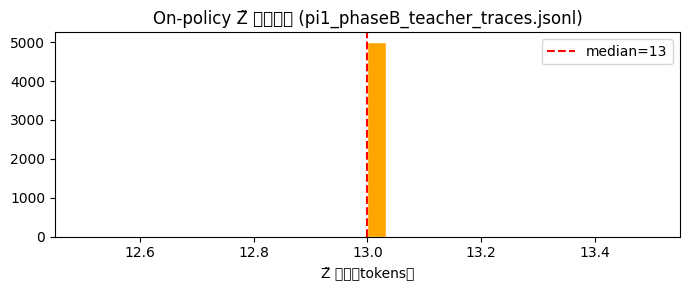

In [16]:
# 如果有 teacher_traces，分析 Z̃ 的 token 分布
if available:
    path = os.path.join(TRACES_DIR, available[0])
    with open(path) as f:
        traces = [json.loads(l) for l in f]
    
    print(f"文件: {available[0]}")
    print(f"行数: {len(traces)}")
    print(f"字段: {list(traces[0].keys())}")
    
    # 展示一条
    t = traces[0]
    print(f"\n示例行:")
    for k, v in t.items():
        print(f"  {k}: {str(v)[:200]}")
    
    # trace 长度分布
    trace_key = next((k for k in t if "trace" in k.lower() or "abs" in k.lower() or "z" in k.lower()), None)
    if trace_key:
        trace_lens = [len(r[trace_key]) if isinstance(r[trace_key], list) else len(str(r[trace_key]).split()) for r in traces]
        plt.figure(figsize=(7, 3))
        plt.hist(trace_lens, bins=30, color="orange", edgecolor="white")
        plt.axvline(np.median(trace_lens), color="red", linestyle="--", label=f"median={int(np.median(trace_lens))}")
        plt.xlabel("Z̃ 长度（tokens）")
        plt.title(f"On-policy Z̃ 长度分布 ({available[0].split('/')[-1]})")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("（跳过，teacher_traces 未下载）")

## 8. 总结验证

| 维度 | 论文描述 | 实现 | 一致？ |
|---|---|---|---|
| **数据来源** | Dolci-Think-SFT (allenai) | `allenai/Dolci-Think-SFT-7B` | ✓ |
| **数据量** | 600k | 5k (1/120) | ✗ (有意缩小) |
| **每行字段** | (prompt, verbal CoT, answer) | `{prompt, cot, answer}` | ✓ |
| **Phase A 序列** | `[X; C; Z̃; Y]` | `X + C + Z + Y` | ✓ |
| **Phase A mask** | Y 不能 attend C | `mask[Y_rows, C_cols] = False` | ✓ |
| **Phase A loss** | 只在 Z̃ ∪ Y | labels=-100 on X,C | ✓ |
| **Phase A round 1** | Z̃ 随机 | `random_abstract_trace()` | ✓ |
| **Phase A round 2+** | Z̃ on-policy | teacher_traces from prev model | ✓ |
| **Phase B 序列** | `[X; Z̃; Y]` (无 CoT) | `X + Z + Y` | ✓ |
| **Phase B mask** | 标准因果 | `attn_mask_2d=None` | ✓ |
| **abstract vocab** | 64 reserved tokens | `V_abs` size=64 | ✓ |